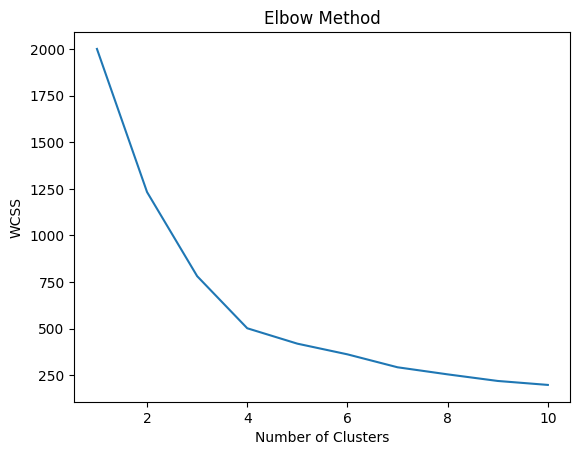

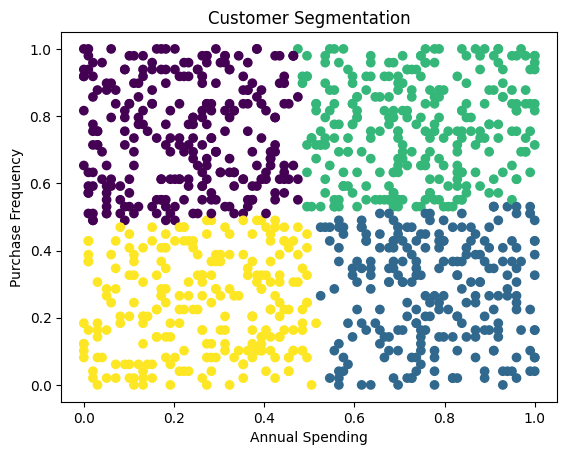

   id  age  gender    income  spending_score  membership_years  \
0   1   38       0  0.577966        0.898990               3.0   
1   2   21       0  0.489436        0.595960               2.0   
2   3   60       0  0.804950        0.292929               2.0   
3   4   40       2  0.142495        0.737374               9.0   
4   5   65       0  0.922047        0.202020               NaN   

   purchase_frequency  preferred_category  last_purchase_amount  Cluster  
0            0.469388                   2              0.104241        1  
1            0.836735                   4              0.031870        2  
2            0.551020                   0              0.418420        0  
3            0.081633                   3              0.992106        1  
4            0.489796                   1              0.340308        0  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('dataset_cleaned.csv')

X = df[['spending_score', 'purchase_frequency']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.scatter(df['spending_score'], df['purchase_frequency'], c=df['Cluster'])
plt.xlabel("Annual Spending")
plt.ylabel("Purchase Frequency")
plt.title("Customer Segmentation")
plt.show()

df.to_csv('final_segmented_customers.csv', index=False)

print(df.head())